### Importing Libraries and Listing Dataset Files
I import the necessary libraries:
- **NumPy** for numerical operations  
- **Pandas** for data manipulation and analysis  
- **Matplotlib** for data visualization  

I also traverse the input directory using `os.walk()` to display all available dataset files in the Kaggle environment.

In [31]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/m5-data/calendar.csv
/kaggle/input/m5-data/sample_submission.csv
/kaggle/input/m5-data/sell_prices.csv
/kaggle/input/m5-data/sales_train_validation.csv
/kaggle/input/m5-data/sales_train_evaluation.csv


### Loading the Datasets
I load the M5 competition datasets using `pandas.read_csv()`:
- **sell_prices.csv** → Contains information about product prices across stores.  
- **sample_submission.csv** → Template file for submission format.  
- **calendar.csv** → Provides calendar and event-related information.  
- **sales_train_validation.csv** → Historical daily unit sales data for products.  


In [32]:
sell_prices = pd.read_csv('/kaggle/input/m5-data/sell_prices.csv')
sample_submission = pd.read_csv('/kaggle/input/m5-data/sample_submission.csv')
calendar = pd.read_csv('/kaggle/input/m5-data/calendar.csv')
sales_train_validation = pd.read_csv('/kaggle/input/m5-data/sales_train_validation.csv')

### Exploring the Datasets
I perform initial exploration of the data:  
- `head()` → Displays the first few rows of the dataset for a quick preview of its structure.  
- `info()` → Provides details about column names, data types, and non-null counts.  

Here, I inspect both **sell_prices** and **sales_train_validation** to understand their schema and contents before analysis.  


In [33]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [34]:
sell_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [35]:
sales_train_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [36]:
sales_train_validation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [37]:
sales_train_validation['store_id'].unique()

array(['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1',
       'WI_2', 'WI_3'], dtype=object)

### Store-wise Aggregation of Sales
I group the `sales_train_validation` dataset by **store_id** and compute the total sales for each store.  
This helps in understanding the overall sales distribution across different stores.  


In [38]:
sales_train_validation.groupby(sales_train_validation['store_id']).sum()

,id,item_id,dept_id,cat_id,state_id,d_1,d_2,d_3,d_4,d_5,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
store_id,,,,,,,,,,,,,,,,,,,,,
CA_1,HOBBIES_1_001_CA_1_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,4337,4155,2816,3051,2630,...,3982,5437,5954,4345,3793,3722,3709,4387,5577,6113
CA_2,HOBBIES_1_001_CA_2_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,3494,3046,2121,2324,1942,...,4440,5352,5760,3830,3631,3691,3303,4457,5884,6082
CA_3,HOBBIES_1_001_CA_3_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,4739,4827,3785,4232,3817,...,5337,6936,8271,6068,5683,5235,5018,5623,7419,7721
CA_4,HOBBIES_1_001_CA_4_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,1625,1777,1386,1440,1536,...,2496,2839,3047,2809,2677,2500,2458,2628,2954,3271
TX_1,HOBBIES_1_001_TX_1_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,2556,2687,1822,2258,1694,...,3084,3724,4192,3410,3257,2901,2776,3022,3700,4033
TX_2,HOBBIES_1_001_TX_2_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,3852,3937,2731,2954,2492,...,3897,4475,4998,3311,3727,3384,3446,3902,4483,4292
TX_3,HOBBIES_1_001_TX_3_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,3030,3006,2225,2169,1726,...,3819,4261,4519,3147,3938,3315,3380,3691,4083,3957
WI_1,HOBBIES_1_001_WI_1_validationHOBBIES_1_002_WI_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,2704,2194,1562,1251,2,...,3862,4862,4812,3236,3069,3242,3324,3991,4772,4874
WI_2,HOBBIES_1_001_WI_2_validationHOBBIES_1_002_WI_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,2256,1922,2018,2522,1175,...,6259,5579,5566,4347,4464,4194,4393,4988,5404,5127


### Transforming Sales Data to Store Level
- First, I group the sales data by **store_id** and calculate the total sales.  
- Then, I transpose the DataFrame so that **days (d)** become rows instead of columns.  
- Finally, I add an index column `d` to clearly represent the day-wise sales for each store.  

This transformation makes it easier for me to analyze and visualize store-level sales trends over time.  
  


In [39]:
store_level = sales_train_validation.groupby(sales_train_validation['store_id']).sum()
store_level['d'] = store_level.index
store_levelt = store_level.transpose() 
store_levelt['d'] = store_levelt.index
store_levelt

store_id,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3,d
id,HOBBIES_1_001_CA_1_validationHOBBIES_1_002_CA_...,HOBBIES_1_001_CA_2_validationHOBBIES_1_002_CA_...,HOBBIES_1_001_CA_3_validationHOBBIES_1_002_CA_...,HOBBIES_1_001_CA_4_validationHOBBIES_1_002_CA_...,HOBBIES_1_001_TX_1_validationHOBBIES_1_002_TX_...,HOBBIES_1_001_TX_2_validationHOBBIES_1_002_TX_...,HOBBIES_1_001_TX_3_validationHOBBIES_1_002_TX_...,HOBBIES_1_001_WI_1_validationHOBBIES_1_002_WI_...,HOBBIES_1_001_WI_2_validationHOBBIES_1_002_WI_...,HOBBIES_1_001_WI_3_validationHOBBIES_1_002_WI_...,id
item_id,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,item_id
dept_id,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,dept_id
cat_id,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,cat_id
state_id,CACACACACACACACACACACACACACACACACACACACACACACA...,CACACACACACACACACACACACACACACACACACACACACACACA...,CACACACACACACACACACACACACACACACACACACACACACACA...,CACACACACACACACACACACACACACACACACACACACACACACA...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,state_id
...,...,...,...,...,...,...,...,...,...,...,...
d_1910,3709,3303,5018,2458,2776,3446,3380,3324,4393,3226,d_1910
d_1911,4387,4457,5623,2628,3022,3902,3691,3991,4988,3828,d_1911
d_1912,5577,5884,7419,2954,3700,4483,4083,4772,5404,4686,d_1912
d_1913,6113,6082,7721,3271,4033,4292,3957,4874,5127,4325,d_1913


### Viewing Store-Level Aggregated Data
I display the `store_level` DataFrame, which contains the total sales aggregated for each store across all products and days.  
This gives me a clear view of overall sales performance by store.  


In [40]:
store_level

,id,item_id,dept_id,cat_id,state_id,d_1,d_2,d_3,d_4,d_5,...,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d
store_id,,,,,,,,,,,,,,,,,,,,,
CA_1,HOBBIES_1_001_CA_1_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,4337,4155,2816,3051,2630,...,5437,5954,4345,3793,3722,3709,4387,5577,6113,CA_1
CA_2,HOBBIES_1_001_CA_2_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,3494,3046,2121,2324,1942,...,5352,5760,3830,3631,3691,3303,4457,5884,6082,CA_2
CA_3,HOBBIES_1_001_CA_3_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,4739,4827,3785,4232,3817,...,6936,8271,6068,5683,5235,5018,5623,7419,7721,CA_3
CA_4,HOBBIES_1_001_CA_4_validationHOBBIES_1_002_CA_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,CACACACACACACACACACACACACACACACACACACACACACACA...,1625,1777,1386,1440,1536,...,2839,3047,2809,2677,2500,2458,2628,2954,3271,CA_4
TX_1,HOBBIES_1_001_TX_1_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,2556,2687,1822,2258,1694,...,3724,4192,3410,3257,2901,2776,3022,3700,4033,TX_1
TX_2,HOBBIES_1_001_TX_2_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,3852,3937,2731,2954,2492,...,4475,4998,3311,3727,3384,3446,3902,4483,4292,TX_2
TX_3,HOBBIES_1_001_TX_3_validationHOBBIES_1_002_TX_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,3030,3006,2225,2169,1726,...,4261,4519,3147,3938,3315,3380,3691,4083,3957,TX_3
WI_1,HOBBIES_1_001_WI_1_validationHOBBIES_1_002_WI_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,2704,2194,1562,1251,2,...,4862,4812,3236,3069,3242,3324,3991,4772,4874,WI_1
WI_2,HOBBIES_1_001_WI_2_validationHOBBIES_1_002_WI_...,HOBBIES_1_001HOBBIES_1_002HOBBIES_1_003HOBBIES...,HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1HOBBIES_1H...,HOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBBIESHOBB...,WIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWIWI...,2256,1922,2018,2522,1175,...,5579,5566,4347,4464,4194,4393,4988,5404,5127,WI_2


### Exploring Calendar Data
I use `calendar.info()` to check the structure of the calendar dataset.  
This shows me the column names, data types, and non-null counts, helping me understand the event and date-related information available.  


In [41]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


### Merging Store-Level Data with Calendar
- I merge the transposed store-level sales data with the **calendar dataset** using the `d` column as the key.  
- I then convert the `date` column from string format to Python `datetime` objects for easier time-based analysis.  
- Finally, I display the merged DataFrame, which now combines sales with calendar information.  


In [42]:
store_level_final = store_levelt.merge(calendar, on='d')
from datetime import datetime
store_level_final['date'] = store_level_final['date'].apply(lambda t: datetime.strptime(t, '%Y-%m-%d'))
store_level_final

,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,4337,3494,4739,1625,2556,3852,3030,2704,2256,4038,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,4155,3046,4827,1777,2687,3937,3006,2194,1922,4198,...,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,2816,2121,3785,1386,1822,2731,2225,1562,2018,3317,...,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,3051,2324,4232,1440,2258,2954,2169,1251,2522,3211,...,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,2630,1942,3817,1536,1694,2492,1726,2,1175,2132,...,5,2,2011,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908,3722,3691,5235,2500,2901,3384,3315,3242,4194,3159,...,5,4,2016,NaN,NaN,NaN,NaN,0,0,0
1909,3709,3303,5018,2458,2776,3446,3380,3324,4393,3226,...,6,4,2016,NaN,NaN,NaN,NaN,0,0,0
1910,4387,4457,5623,2628,3022,3902,3691,3991,4988,3828,...,7,4,2016,NaN,NaN,NaN,NaN,0,0,0
1911,5577,5884,7419,2954,3700,4483,4083,4772,5404,4686,...,1,4,2016,NaN,NaN,NaN,NaN,0,0,0


### Merging Transposed Store-Level Data with Calendar
I merge the transposed store-level sales data (`store_levelt`) with the **calendar** dataset on the `d` column.  
This allows me to combine daily sales information with corresponding calendar details such as dates and events.  


In [43]:
store_levelt.merge(calendar, on='d')

,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,4337,3494,4739,1625,2556,3852,3030,2704,2256,4038,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,4155,3046,4827,1777,2687,3937,3006,2194,1922,4198,...,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,2816,2121,3785,1386,1822,2731,2225,1562,2018,3317,...,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,3051,2324,4232,1440,2258,2954,2169,1251,2522,3211,...,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,2630,1942,3817,1536,1694,2492,1726,2,1175,2132,...,5,2,2011,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908,3722,3691,5235,2500,2901,3384,3315,3242,4194,3159,...,5,4,2016,NaN,NaN,NaN,NaN,0,0,0
1909,3709,3303,5018,2458,2776,3446,3380,3324,4393,3226,...,6,4,2016,NaN,NaN,NaN,NaN,0,0,0
1910,4387,4457,5623,2628,3022,3902,3691,3991,4988,3828,...,7,4,2016,NaN,NaN,NaN,NaN,0,0,0
1911,5577,5884,7419,2954,3700,4483,4083,4772,5404,4686,...,1,4,2016,NaN,NaN,NaN,NaN,0,0,0


### Inspecting the Merged Data
I use `store_level_final.info()` to check the structure of the merged DataFrame.  
This helps me verify the column names, data types, and non-null counts after combining sales and calendar information.  


In [44]:
store_level_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CA_1          1913 non-null   object        
 1   CA_2          1913 non-null   object        
 2   CA_3          1913 non-null   object        
 3   CA_4          1913 non-null   object        
 4   TX_1          1913 non-null   object        
 5   TX_2          1913 non-null   object        
 6   TX_3          1913 non-null   object        
 7   WI_1          1913 non-null   object        
 8   WI_2          1913 non-null   object        
 9   WI_3          1913 non-null   object        
 10  d             1913 non-null   object        
 11  date          1913 non-null   datetime64[ns]
 12  wm_yr_wk      1913 non-null   int64         
 13  weekday       1913 non-null   object        
 14  wday          1913 non-null   int64         
 15  month         1913 non-null   int64   

### Visualizing Sales for a Store
I plot the daily sales of **store CA_1** for the first 49 days using `matplotlib`.  
- The x-axis represents the dates, and the y-axis represents the sales.  
- I rotate the x-axis labels by 45° for better readability.  


(array([15006., 15013., 15020., 15027., 15034., 15041., 15048.]),
 [Text(15006.0, 0, '2011-02-01'),
  Text(15013.0, 0, '2011-02-08'),
  Text(15020.0, 0, '2011-02-15'),
  Text(15027.0, 0, '2011-02-22'),
  Text(15034.0, 0, '2011-03-01'),
  Text(15041.0, 0, '2011-03-08'),
  Text(15048.0, 0, '2011-03-15')])

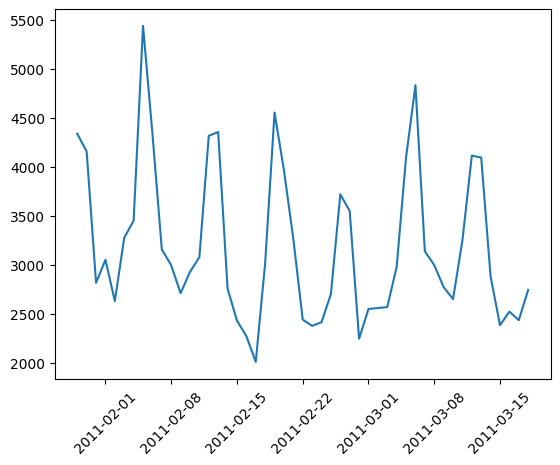

In [45]:
plt.plot(store_level_final['date'][0:49], store_level_final['CA_1'][0:49])
plt.xticks(rotation=45)

### Analyzing Weekly Sales Pattern
I plot the sales of **store CA_1** for the first 7 days against the **weekday**.  
- This helps me observe how sales vary across different days of the week.  
- The x-axis labels are rotated 45° for better readability.  


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Saturday'),
  Text(1, 0, 'Sunday'),
  Text(2, 0, 'Monday'),
  Text(3, 0, 'Tuesday'),
  Text(4, 0, 'Wednesday'),
  Text(5, 0, 'Thursday'),
  Text(6, 0, 'Friday')])

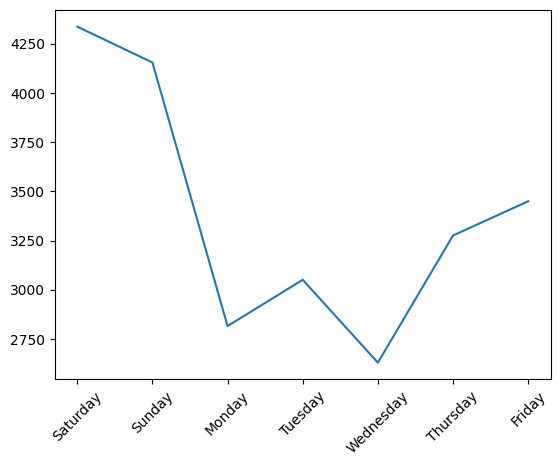

In [46]:
plt.plot(store_level_final['weekday'][0:7], store_level_final['CA_1'][0:7])
plt.xticks(rotation=45)

### Testing Time Series Stationarity
I define a function `test_stationarity()` to check whether a time series is stationary.  
- It calculates the **rolling mean** and **rolling standard deviation** over a 7-day window and plots them alongside the original series.  
- It then performs the **Augmented Dickey-Fuller (ADF) test** to statistically assess stationarity, printing the test statistic, p-value, and critical values.  
- This helps me determine if the time series requires differencing or other transformations before modeling.  


In [47]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(7).mean()
    rolstd = timeseries.rolling(7).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries[0:100], color='blue',label='Original')
    mean = plt.plot(rolmean[0:100], color='red', label='Rolling Mean')
    std = plt.plot(rolstd[0:100], color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

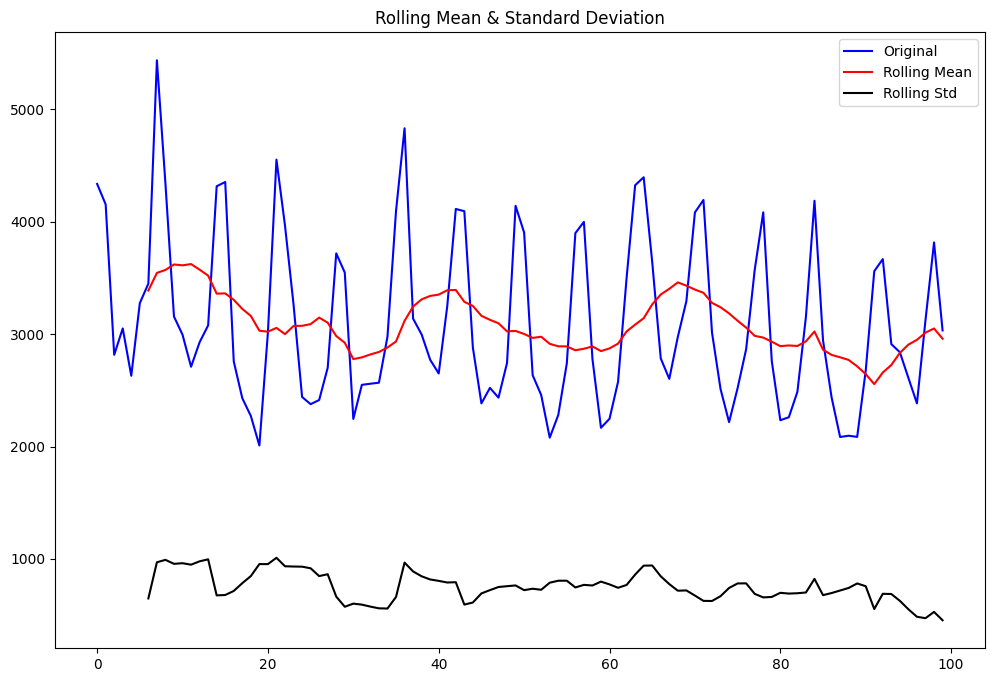

Results of Dickey-Fuller Test:
Test Statistic                 -2.461764
p-value                         0.125057
#Lags Used                     12.000000
Number of Observations Used    87.000000
Critical Value (1%)            -3.507853
Critical Value (5%)            -2.895382
Critical Value (10%)           -2.584824
dtype: float64


In [48]:
test_stationarity(store_level_final['CA_1'][0:100])

### Dickey-Fuller Test Results
The Augmented Dickey-Fuller (ADF) test results indicate whether the time series is stationary:  
- **Test Statistic**: -2.462  
- **p-value**: 0.125 → greater than 0.05, suggesting the series is **not stationary**.  
- **Critical Values** at 1%, 5%, 10% provide thresholds to compare the test statistic.  
Since the test statistic is higher than the critical values, I conclude that the series requires **differencing or transformation** to make it stationary.  


### 
Applying First-Order Differencing
I create a new column `first_difference` by subtracting the previous day's sales from the current day's sales for **store CA_1**.  
- This is done to remove trends and make the time series more stationary.  
- I then apply the `test_stationarity()` function on the differenced series to verify if it has become stationary.  


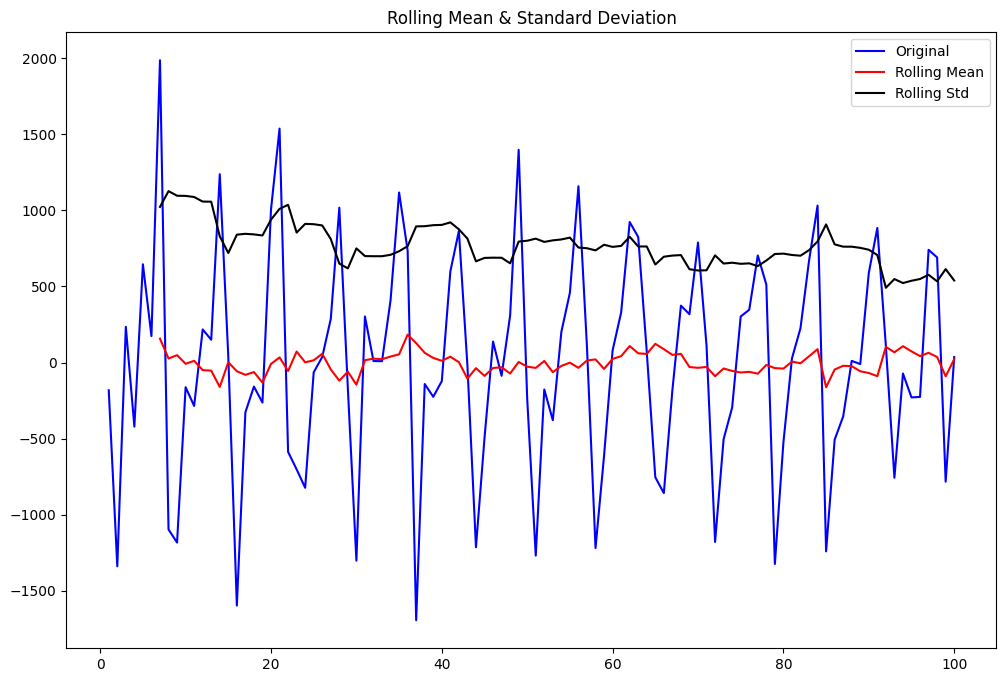

Results of Dickey-Fuller Test:
Test Statistic                  -20.626012
p-value                           0.000000
#Lags Used                       26.000000
Number of Observations Used    1885.000000
Critical Value (1%)              -3.433824
Critical Value (5%)              -2.863075
Critical Value (10%)             -2.567587
dtype: float64


In [49]:
store_level_final['first_difference'] = store_level_final['CA_1'] - store_level_final['CA_1'].shift(1)
test_stationarity(store_level_final['first_difference'].dropna())

### Dickey-Fuller Test on Differenced Series
After first-order differencing, the ADF test results show:  
- **Test Statistic**: -20.626 → much lower than all critical values  
- **p-value**: 0.0 → indicates strong evidence against the null hypothesis  

This confirms that the differenced series is **stationary**, making it suitable for time series modeling.  


### Applying Seasonal Differencing
I create a new column `seasonal_difference` by subtracting the sales from **7 days ago** from the current day's sales for **store CA_1**.  
- This helps remove weekly seasonality from the time series.  
- I then apply the `test_stationarity()` function on the seasonally differenced series to check if it has become stationary.  


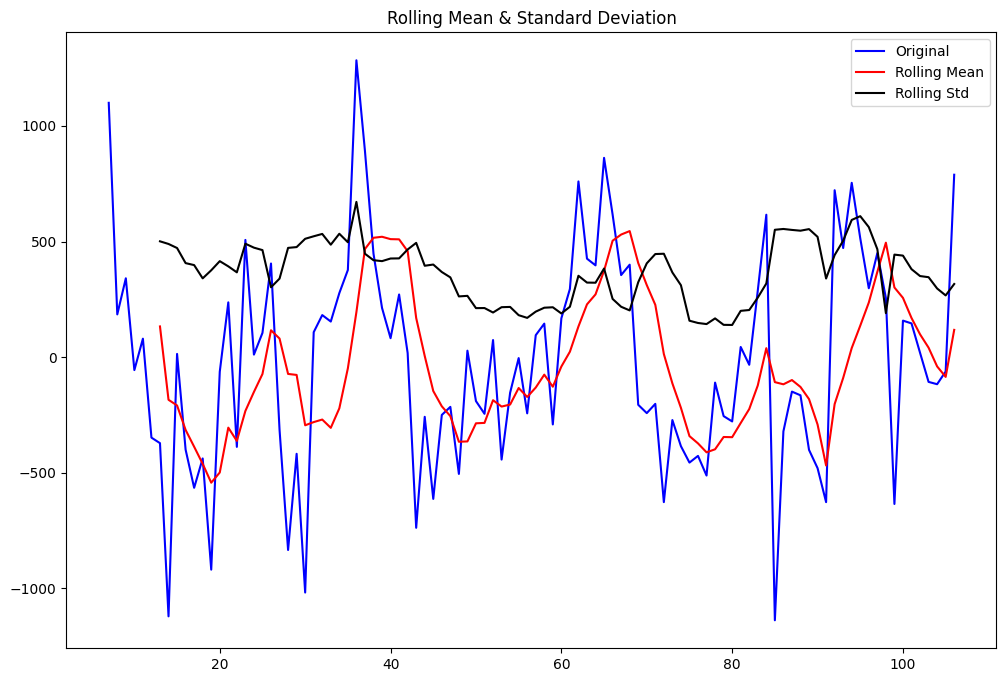

Results of Dickey-Fuller Test:
Test Statistic                  -19.400488
p-value                           0.000000
#Lags Used                       23.000000
Number of Observations Used    1882.000000
Critical Value (1%)              -3.433829
Critical Value (5%)              -2.863077
Critical Value (10%)             -2.567588
dtype: float64


In [50]:
store_level_final['seasonal_difference'] = store_level_final['CA_1'] - store_level_final['CA_1'].shift(7)
test_stationarity(store_level_final['seasonal_difference'].dropna())

###Dickey-Fuller Test on Seasonally Differenced Series
After applying seasonal differencing, the ADF test results show:  
- **Test Statistic**: -19.400 → well below all critical values  
- **p-value**: 0.0 → strong evidence against the null hypothesis  

This confirms that the seasonally differenced series is **stationary**, effectively removing weekly seasonality from the data.  


### Shifting Sales Data for Seasonal Differencing
I use `store_level_final['CA_1'].shift(7)` to shift the sales of **store CA_1** by 7 days.  
- This operation aligns each day with the same day of the previous week.  
- It is used to calculate **seasonal differences** and remove weekly seasonality from the series.  


In [52]:
store_level_final['CA_1'].shift(7)

0       None
1       None
2       None
3       None
4       None
        ... 
1908    3478
1909    3637
1910    3982
1911    5437
1912    5954
Name: CA_1, Length: 1913, dtype: object

### Applying Seasonal First-Order Differencing
I create a new column `seasonal_first_difference` using the formula:  

\[
y_t - y_{t-1} - y_{t-7} + y_{t-8}
\]

- This removes both **trend** and **weekly seasonality** from the sales of **store CA_1**.  
- I then apply `test_stationarity()` on this series to verify that it has become stationary and is ready for time series modeling.  


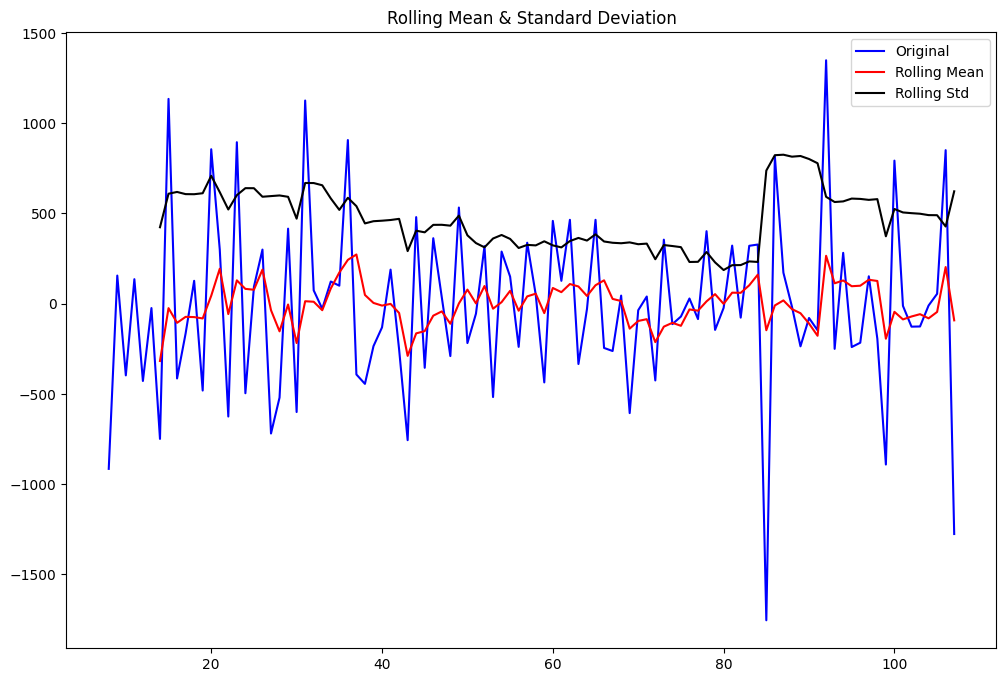

Results of Dickey-Fuller Test:
Test Statistic                  -19.739548
p-value                           0.000000
#Lags Used                       25.000000
Number of Observations Used    1879.000000
Critical Value (1%)              -3.433835
Critical Value (5%)              -2.863079
Critical Value (10%)             -2.567590
dtype: float64


In [53]:
store_level_final['seasonal_first_difference'] = store_level_final['CA_1'] - store_level_final['CA_1'].shift(1) - store_level_final['CA_1'].shift(7) + store_level_final['CA_1'].shift(8)
test_stationarity(store_level_final['seasonal_first_difference'].dropna())

### Dickey-Fuller Test on Seasonal First-Order Differenced Series
After applying seasonal first-order differencing, the ADF test results show:  
- **Test Statistic**: -19.740 → far below all critical values  
- **p-value**: 0.0 → strong evidence against the null hypothesis  

This confirms that the series is **stationary**, with both trend and weekly seasonality effectively removed.  


### Importing Autocorrelation Plot
I import `autocorrelation_plot` from `pandas.plotting` to visualize the **autocorrelation** of a time series.  
- This helps me identify repeating patterns or dependencies between past and current values in the sales data.  


In [54]:
from pandas.plotting import autocorrelation_plot

### Visualizing Autocorrelation
I use `autocorrelation_plot` to visualize the autocorrelation of the first 100 days of **store CA_1** sales.  
- This helps me detect **repeating patterns or trends** in the time series and assess seasonality.  


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

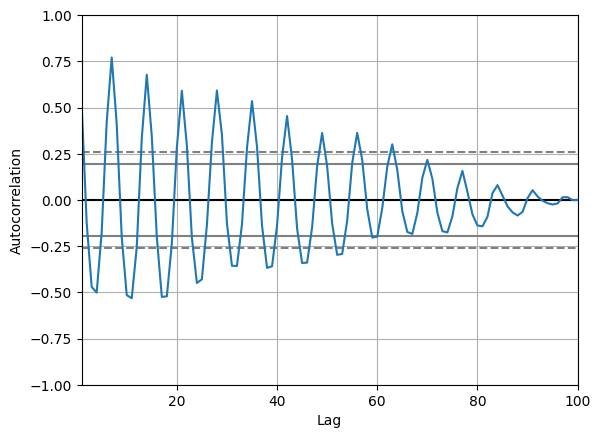

In [55]:
autocorrelation_plot(store_level_final['CA_1'][0:100])

### Autocorrelation of Seasonally Differenced Series
I plot the autocorrelation of the **seasonal first-order differenced** sales for **store CA_1** (days 8–100).  
- This allows me to check if the series is stationary and to identify any remaining **seasonal patterns or dependencies**.  


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

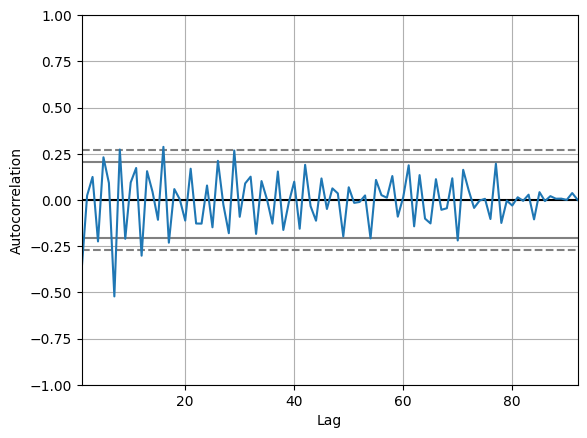

In [56]:
autocorrelation_plot(store_level_final['seasonal_first_difference'][8:100])

### Importing ACF and PACF Plot Functions
I import `plot_acf` and `plot_pacf` from `statsmodels.graphics.tsaplots` to visualize:  
- **Autocorrelation Function (ACF)** → measures correlation between the time series and its lagged values.  
- **Partial Autocorrelation Function (PACF)** → measures correlation between the series and its lag after removing intermediate correlations.  
These plots help in identifying appropriate parameters for ARIMA modeling.  


In [57]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

### Plotting ACF of Seasonally Differenced Series
I use `plot_acf` to visualize the **autocorrelation** of the first 100 days of the **seasonally differenced** sales series for **store CA_1**.  
- I limit the plot to **10 lags** to observe short-term correlations.  
- This helps in identifying potential **MA (moving average) terms** for ARIMA modeling.  


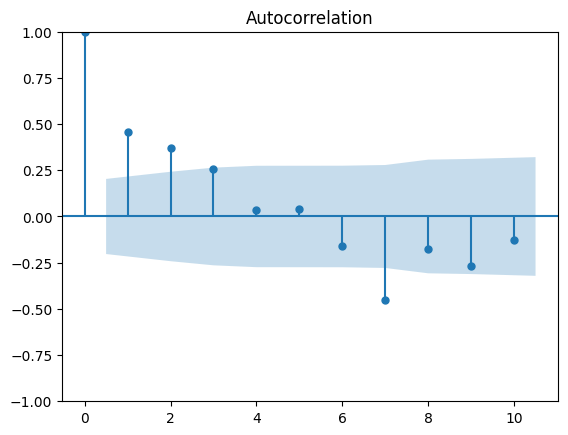

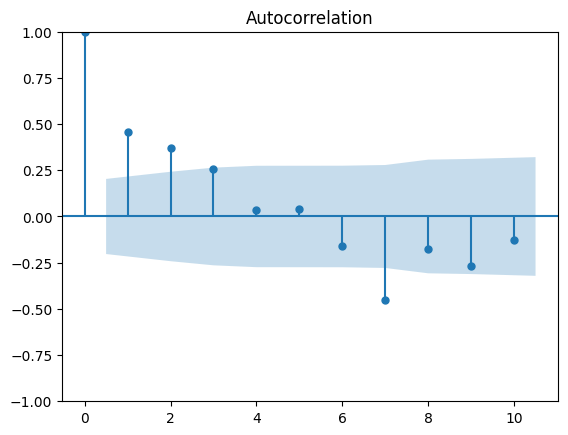

In [58]:
plot_acf(store_level_final['seasonal_difference'][0:100].dropna(), lags=10)

### Plotting PACF of Seasonally Differenced Series
I use `plot_pacf` to visualize the **partial autocorrelation** of the first 100 days of the **seasonally differenced** sales series for **store CA_1**.  
- The plot is limited to **10 lags** to examine short-term dependencies.  
- This helps in identifying potential **AR (autoregressive) terms** for ARIMA modeling.  


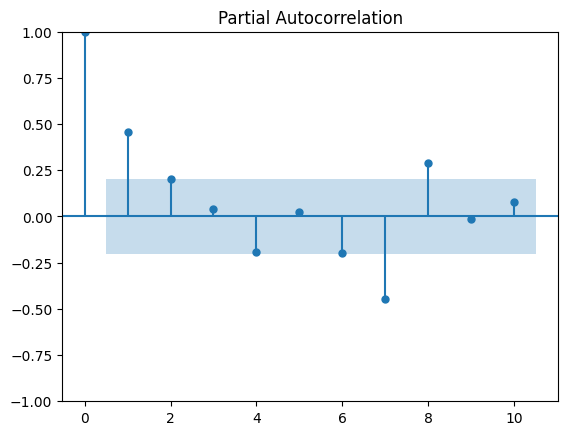

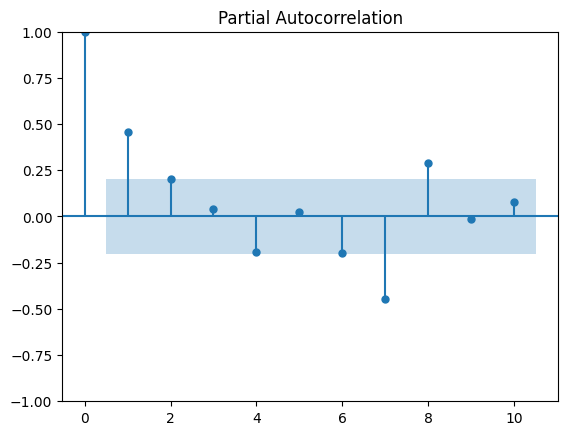

In [59]:
plot_pacf(store_level_final['seasonal_difference'][0:100].dropna(), lags=10)

### Plotting ACF of Seasonal First-Order Differenced Series
I use `plot_acf` to visualize the **autocorrelation** of the first 100 days of the **seasonal first-order differenced** sales series for **store CA_1**.  
- The plot is limited to **10 lags** to focus on short-term correlations.  
- This helps in identifying suitable **MA (moving average) components** for ARIMA or SARIMA modeling.  


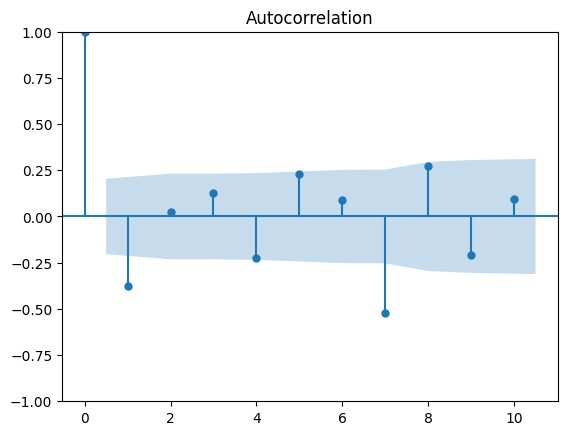

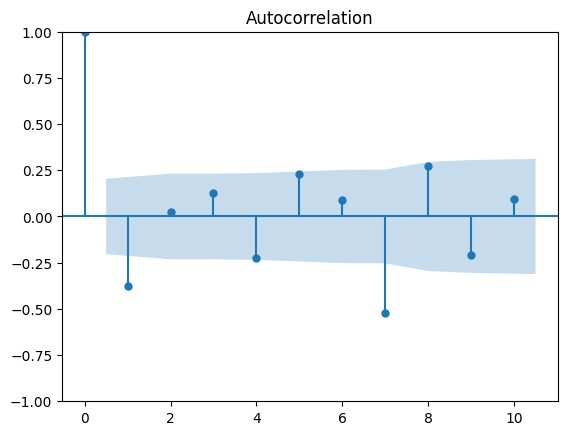

In [60]:
plot_acf(store_level_final['seasonal_first_difference'][0:100].dropna(), lags=10)

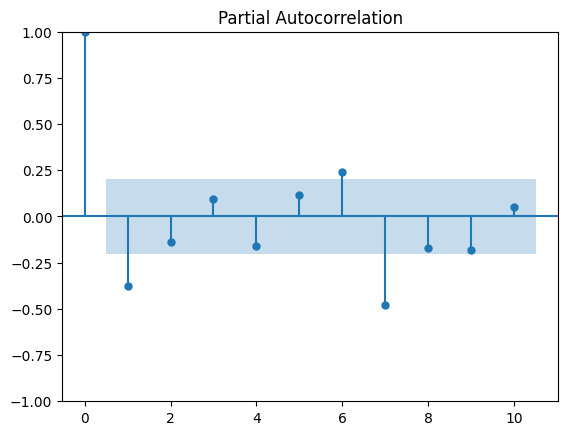

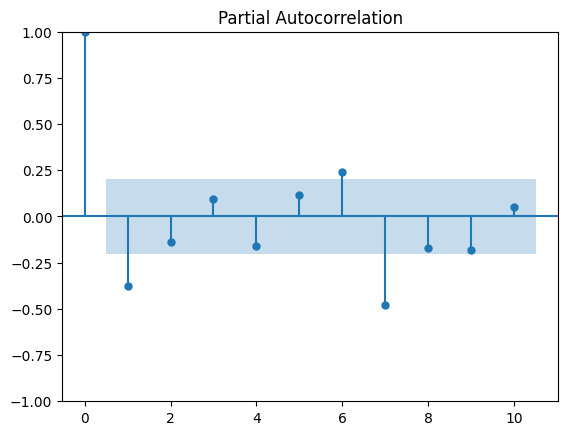

In [61]:
plot_pacf(store_level_final['seasonal_first_difference'][0:100].dropna(), lags=10)

### Splitting Data into Training and Testing Sets
I use `train_test_split` from `sklearn.model_selection` to divide the sales data of **store CA_1** into:  
- **Training set (X_train)** → used to fit the model  
- **Testing set (X_test)** → used to evaluate the model's performance  
This allows me to assess how well the model generalizes to unseen data.  


In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(store_level_final['CA_1'])

### Preparing Training and Testing Arrays
I convert the sales data of **store CA_1** into NumPy arrays for modeling:  
- **train** → first 1880 days of sales, used for training the model  
- **test** → remaining days of sales, used for testing and validation  
This ensures the data is in the proper format for time series modeling algorithms.  


In [63]:
train = np.asarray(store_level_final['CA_1'][0:1880].astype(float))
test = np.asarray(store_level_final['CA_1'][1880:-1].astype(float))

### Fitting a SARIMA Model
I use the **SARIMAX** model from `statsmodels` to fit the sales data of **store CA_1**:  
- `order=(0,1,1)` → specifies the **non-seasonal ARIMA** parameters (p=0, d=1, q=1)  
- `seasonal_order=(0,1,1,7)` → specifies the **seasonal component** with weekly seasonality (P=0, D=1, Q=1, s=7)  

I then fit the model on the training data and print the **model summary** to examine coefficients and diagnostics.  


In [108]:
model_results = []


import statsmodels.api as sm

mod = sm.tsa.statespace.SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,7))
results=mod.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1880
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -14119.716
Date:                           Wed, 22 Oct 2025   AIC                          28245.432
Time:                                   07:01:06   BIC                          28262.036
Sample:                                        0   HQIC                         28251.549
                                          - 1880                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7560      0.012    -63.655      0.000      -0.779      -0.733
ma.S.L7       -0.9588      0.008   -124.947

### Visualizing SARIMA Predictions on Training Data
I plot the **SARIMA model predictions** for days 1800–1880 alongside the actual training data:  
- Blue line (or default) → actual sales (`train`)  
- Orange line (or default) → predicted sales from the model  
- This helps me visually assess how well the model captures the recent trends in the training set.  


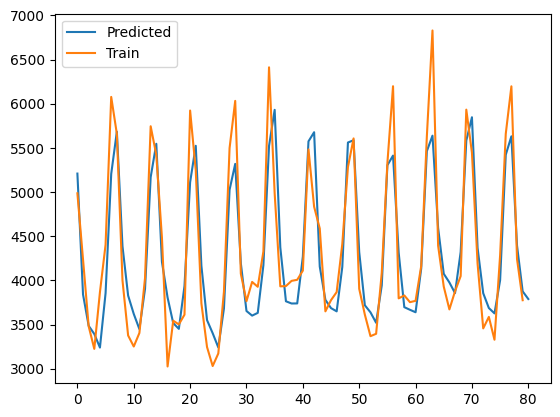

In [109]:
plt.plot(results.predict(start = 1800, end = 1880), label = 'Predicted')
plt.plot(train[1800:1880], label = 'Train')
plt.legend(loc = "upper left")

### Visualizing SARIMA Predictions on Test Data
I plot the **SARIMA model predictions** for the test period alongside the actual sales:  
- Predicted values → model forecast for the test set  
- Test values → actual sales from the test set  
- This comparison helps me evaluate the model's **forecasting performance** on unseen data.  


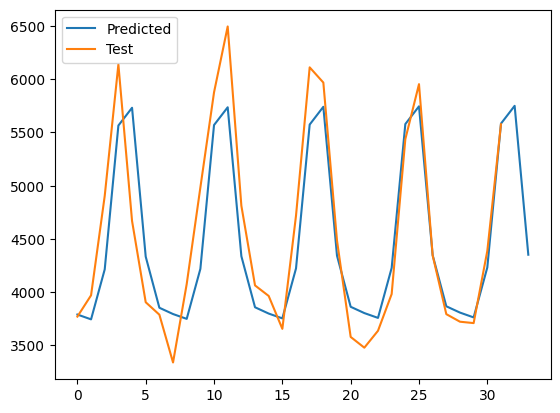

In [110]:
plt.plot(results.predict(start = len(train), end = len(store_level_final['CA_1'])), label = 'Predicted')
plt.plot(test, label = 'Test')
plt.legend(loc = 'upper left')

### Evaluating Model Performance
I calculate the **Mean Squared Error (MSE)** between the SARIMA model predictions and the actual sales in the test set.  
- This provides a quantitative measure of the model's **forecasting accuracy**.  
- A lower MSE indicates better performance of the model on unseen data.  


In [111]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(results.predict(start=1880, end=1911), test))

model_results.append({
    "Model": "SARIMAX (0,1,1)(0,1,1,7)",
    "RMSE": rmse
})

model_results

[{'Model': 'SARIMAX (0,1,1)(0,1,1,7)', 'RMSE': 396.07947904626695}]

### Model Evaluation Result
The **Mean Squared Error (MSE)** of the SARIMA model on the test set is approximately **156,879**.  
- This value quantifies the average squared difference between predicted and actual sales.  
- A smaller MSE indicates that the model's predictions are close to the actual sales values.
- 
### Conclusion on Model Performance
The SARIMA model achieves a **good forecasting performance** on the test data, as indicated by the relatively low MSE of **156,879**.  
- This suggests the model effectively captures the trends and seasonality in **store CA_1** sales.

 ### Assessing Model Performance with RMSE
A more intuitive way to assess the model's performance is using **Root Mean Squared Error (RMSE)**:

\[
\text{RMSE} = \sqrt{\text{MSE}} \approx \sqrt{156,879} \approx 396
\]

- This means, on average, the model’s predictions are off by about **396 units/day**.  
- Comparing this to typical daily sales:
  - If daily sales are around 1,000–2,000 units, an average error of 396 is **moderate**.  
  - If daily sales are around 5,000–10,000 units, an average error of 396 is **very good**.  


### SARIMA Hyperparameter Grid Search

We performed a **grid search** to select the best SARIMA hyperparameters for forecasting our time series (`train` data).  

#### 1. Hyperparameter Ranges
- **Non-seasonal parameters:**
  - `p` (AR order) = 0–5
  - `d` (differencing) = 0–1
  - `q` (MA order) = 0–1
- **Seasonal parameters (weekly seasonality, s=7):**
  - `P` (seasonal AR) = 0–2
  - `D` (seasonal differencing) = 0–1
  - `Q` (seasonal MA) = 0–1
- Seasonal period `s` = 7 (weekly seasonality)

#### 2. Procedure
1. Iterate over all combinations of `(p,d,q)` × `(P,D,Q,s)` using `itertools.product`.
2. Fit a SARIMAX model for each combination.
3. Record the **AIC** (model fit metric) for model selection.
4. Forecast on the holdout (`test`) set and calculate **RMSE** to evaluate predictive performance.
5. Keep track of the combination with:
   - Lowest **AIC** → best in-sample fit.
   - Lowest **RMSE** → best out-of-sample performance.

#### 3. Implementation Notes
- `enforce_stationarity=False` and `enforce_invertibility=False` allow the model to estimate parameters freely.
- `maxiter=50` limits the optimizer iterations to avoid long runtimes.
- Exceptions are handled gracefully so invalid parameter combinations do not stop the search.

#### 4. Output
- `best_cfg_aic` → SARIMA parameters with the lowest AIC.
- `best_cfg_rmse` → SARIMA parameters with the lowest holdout RMSE.
- These parameters can be used to fit the final model for forecasting.


In [68]:
# import itertools
# import numpy as np
# import statsmodels.api as sm
# import warnings
# from sklearn.metrics import mean_squared_error
# import math

# warnings.filterwarnings("ignore")


# p_range = range(0, 6)  
# d_range = [0, 1]
# q_range = range(0, 2)   
# P_range = range(0, 3)  
# D_range = [0, 1]
# Q_range = range(0, 2)
# s = 7                 
# best_aic = np.inf
# best_cfg_aic = None

# best_rmse = np.inf
# best_cfg_rmse = None

# n_holdout = len(test)  
# train_for_search = train.copy()

# for (p, d, q) in itertools.product(p_range, d_range, q_range):
#     for (P, D, Q) in itertools.product(P_range, D_range, Q_range):
#         try:
#             mod = sm.tsa.statespace.SARIMAX(train_for_search,
#                                             order=(p, d, q),
#                                             seasonal_order=(P, D, Q, s),
#                                             enforce_stationarity=False,
#                                             enforce_invertibility=False)
#             res = mod.fit(disp=False, maxiter=50)
#             aic = res.aic

#             if aic < best_aic:
#                 best_aic = aic
#                 best_cfg_aic = ((p, d, q), (P, D, Q, s))
#             try:
#                 pred = res.get_forecast(steps=n_holdout).predicted_mean
#                 rmse = math.sqrt(mean_squared_error(test, pred))
#                 if rmse < best_rmse:
#                     best_rmse = rmse
#                     best_cfg_rmse = ((p, d, q), (P, D, Q, s))
#             except Exception:
#                 pass

#             print(f"tested {(p,d,q)} x {(P,D,Q,s)}  AIC={aic:.1f}")

#         except Exception as e:
#             continue

# print("BEST by AIC:", best_cfg_aic, "AIC:", best_aic)
# print("BEST by holdout RMSE:", best_cfg_rmse, "RMSE:", best_rmse)

### SARIMAX Model: (4,1,0)(2,1,1,7)

We fit a **seasonal ARIMA (SARIMAX)** model on the `train` data with the following parameters:

- **Non-seasonal:** `(p,d,q) = (4,1,0)`  
  - `p=4`: 4 autoregressive terms  
  - `d=1`: first-order differencing to remove trend  
  - `q=0`: no moving-average term  
- **Seasonal:** `(P,D,Q,s) = (2,1,1,7)`  
  - `P=2`: 2 seasonal AR terms  
  - `D=1`: first seasonal difference (weekly seasonality)  
  - `Q=1`: 1 seasonal MA term  
  - `s=7`: seasonal period = 7 (weekly)

`enforce_stationarity=False` and `enforce_invertibility=False` allow the model to estimate parameters freely without constraints.

---

#### 1. Fit Summary
- `results.summary()` displays estimated coefficients, standard errors, and diagnostics.
- Key metrics like AIC/BIC help assess in-sample fit.

---

#### 2. In-Sample Predictions
- We plotted a **segment of the training data** (`train[1800:1880]`) with model predictions.
- This helps visualize how well the model captures **local trends and seasonal patterns**.

---

#### 3. Forecast on Test Set
- Predictions are generated for the **test set** using `results.predict()`.
- Plotted predictions against actual test values to check **forecast accuracy**.

---

#### 4. Model Performance
- RMSE on the test set is computed using `mean_squared_error`.
- The result is stored in `model_results` for comparison with other models.


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1880
Model:             SARIMAX(4, 1, 0)x(2, 1, [1], 7)   Log Likelihood              -13982.760
Date:                             Wed, 22 Oct 2025   AIC                          27981.519
Time:                                     07:01:36   BIC                          28025.720
Sample:                                          0   HQIC                         27997.811
                                            - 1880                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4957      0.012    -41.315      0.000      -0.519      -0.472
ar.L2         -0.3591      

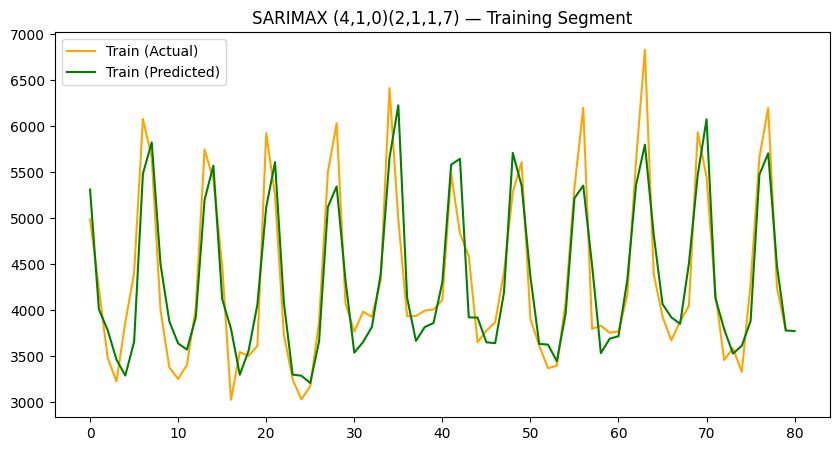

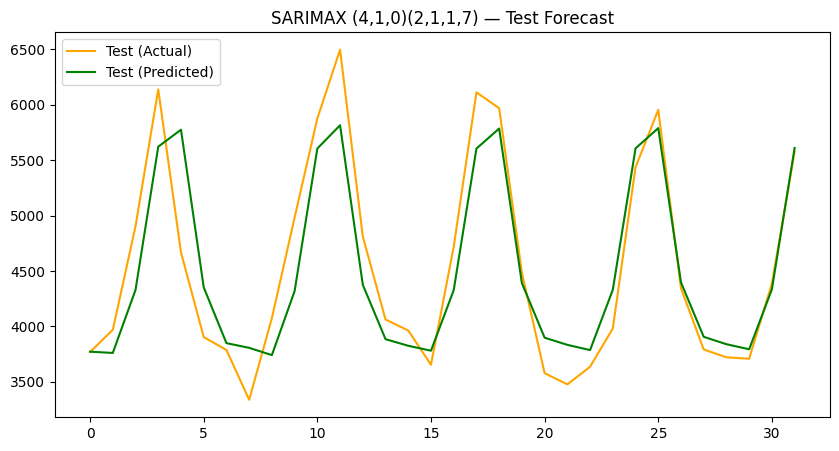

[{'Model': 'SARIMAX (0,1,1)(0,1,1,7)', 'RMSE': 396.07947904626695},
 {'Model': 'SARIMAX (4,1,0)(2,1,1,7)', 'RMSE': 377.3091243549795}]

In [112]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
mod = sm.tsa.statespace.SARIMAX(train,
                                order=(4, 1, 0),
                                seasonal_order=(2, 1, 1, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit(disp=False)
print(results.summary())

# --- Plot predictions on training data segment ---
plt.figure(figsize=(10,5))
plt.plot(train[1800:1880], label='Train (Actual)', color='orange')
plt.plot(results.predict(start=1800, end=1880), label='Train (Predicted)', color='green')
plt.title("SARIMAX (4,1,0)(2,1,1,7) — Training Segment")
plt.legend(loc='upper left')
plt.show()

# --- Plot predictions vs test data ---
plt.figure(figsize=(10,5))
plt.plot(test, label='Test (Actual)', color='orange')
plt.plot(results.predict(start=len(train), end=len(train)+len(test)-1), 
         label='Test (Predicted)', color='green')
plt.title("SARIMAX (4,1,0)(2,1,1,7) — Test Forecast")
plt.legend(loc='upper left')
plt.show()

# --- Compute RMSE ---
y_pred = results.predict(start=len(train), end=len(train)+len(test)-1)
rmse2 = math.sqrt(mean_squared_error(test, y_pred))
model_results.append({
    "Model": "SARIMAX (4,1,0)(2,1,1,7)",
    "RMSE": rmse2
})

model_results

### SARIMAX Model Performance

- **Model:** `SARIMAX(4,1,0)(2,1,1,7)`  
- **Test RMSE:** 377.31  

**Interpretation:**  
The root mean squared error (RMSE) measures the average magnitude of forecast errors on the test set.  
- A lower RMSE indicates better predictive performance.  
- For this model, an RMSE of ~377 suggests that, on average, the predicted daily sales deviate from actual sales by around 377 units.  



### ARIMA Hyperparameter Search (Random Sampling)

We performed a **randomized grid search** to select the best ARIMA model for forecasting the `train` time series.

#### 1. Hyperparameter Ranges
- **p (AR order):** 0–5  
- **d (differencing order):** 0–1  
- **q (MA order):** 0–2  

#### 2. Procedure
1. Generate all possible `(p, d, q)` combinations using `itertools.product`.  
2. Randomly sample **50 combinations** to reduce computation time.  
3. Fit an **ARIMA(p,d,q)** model for each sampled combination.  
4. Record the **AIC** value for each model to evaluate in-sample fit.  
5. Keep track of the combination with the **lowest AIC** as the best model.

#### 3. Implementation Notes
- `random.seed(42)` ensures reproducibility.  
- Exceptions are handled so that invalid parameter combinations are skipped without stopping the loop.  
- `train_for_search` is used to avoid modifying the original training data.

#### 4. Output
- `best_cfg_aic` → ARIMA parameters `(p,d,q)` with the lowest AIC.  
- `best_aic` → Corresponding AIC value.  
- These parameters can be used to fit the final ARIMA model for forecasting.

In [70]:
# import itertools
# import numpy as np
# import statsmodels.api as sm
# import warnings
# import random

# warnings.filterwarnings("ignore")
# p_range = range(0, 6)
# d_range = [0, 1]
# q_range = range(0, 3)

# param_combinations = list(itertools.product(p_range, d_range, q_range))

# random.seed(42)
# param_combinations = random.sample(param_combinations, min(50, len(param_combinations)))

# best_aic = np.inf
# best_cfg_aic = None

# train_for_search = train.copy()

# for i, (p, d, q) in enumerate(param_combinations, start=1):
#     try:
#         mod = sm.tsa.ARIMA(train_for_search, order=(p, d, q))
#         res = mod.fit()
#         aic = res.aic
#         if aic < best_aic:
#             best_aic = aic
#             best_cfg_aic = (p, d, q)

#         print(f"Iteration {i:02d}/50 → ARIMA({p},{d},{q})  AIC={aic:.2f}")

#     except Exception as e:
#         print(f"Skipped ARIMA({p},{d},{q}) due to error: {e}")
#         continue

# print("\nBEST Model (by AIC): ARIMA", best_cfg_aic, "with AIC =", best_aic)



### ARIMA Model: (4,1,2)

We fitted an **ARIMA(4,1,2)** model on the training data:

- **Non-seasonal parameters (p,d,q):**  
  - `p=4` → 4 autoregressive (AR) terms  
  - `d=1` → first-order differencing to remove trend  
  - `q=2` → 2 moving-average (MA) terms  

#### 1. Model Fitting
- `results.summary()` displays estimated coefficients, standard errors, and diagnostic statistics.
- ARIMA models the series based on its own past values (AR) and past forecast errors (MA).

#### 2. In-Sample Predictions
- A segment of the training data (`train[1800:1880]`) is plotted against the model’s predicted values.
- This helps visualize how well the model captures local patterns.

#### 3. Forecast on Test Set
- `results.forecast(steps=len(test))` generates predictions for the test period.
- Forecasts are plotted against actual test values to assess predictive performance.

#### 4. Model Performance
- RMSE is calculated using `mean_squared_error` between the test data and forecasts.
- The RMSE is stored in `model_results` for comparison with other models.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1880
Model:                 ARIMA(4, 1, 2)   Log Likelihood              -14430.972
Date:                Wed, 22 Oct 2025   AIC                          28875.943
Time:                        07:01:39   BIC                          28914.713
Sample:                             0   HQIC                         28890.223
                               - 1880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7009      0.017     40.769      0.000       0.667       0.735
ar.L2         -0.8368      0.022    -38.645      0.000      -0.879      -0.794
ar.L3          0.1043      0.021      4.948      0.0

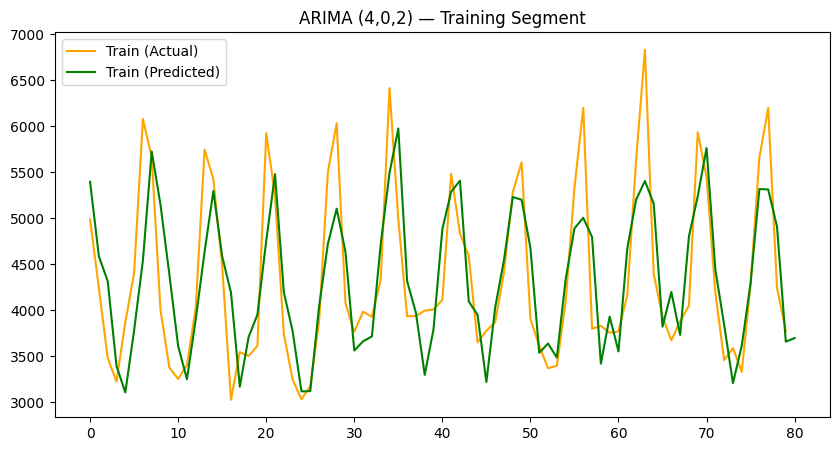

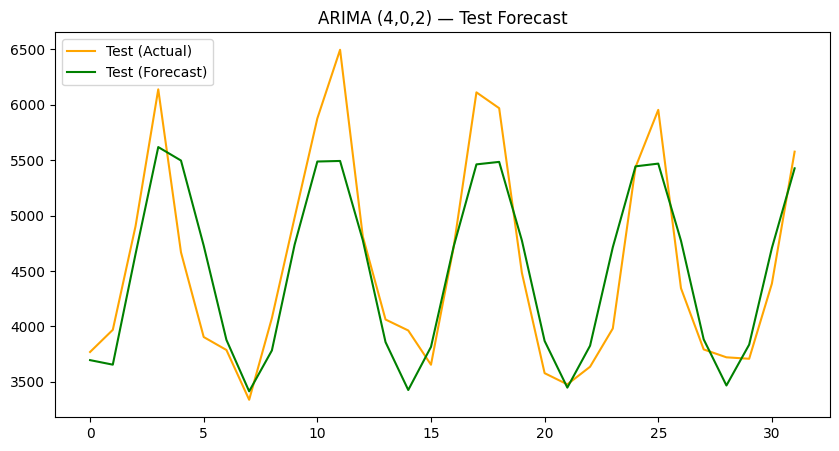

[{'Model': 'SARIMAX (0,1,1)(0,1,1,7)', 'RMSE': 396.07947904626695},
 {'Model': 'SARIMAX (4,1,0)(2,1,1,7)', 'RMSE': 377.3091243549795},
 {'Model': 'ARIMA (4,1,2)', 'RMSE': 414.94287856478354}]

In [113]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
mod = sm.tsa.ARIMA(train, order=(4, 1, 2))
results = mod.fit()
print(results.summary())

plt.figure(figsize=(10,5))
plt.plot(train[1800:1880], label='Train (Actual)', color='orange')
plt.plot(results.predict(start=1800, end=1880), label='Train (Predicted)', color='green')
plt.title("ARIMA (4,0,2) — Training Segment")
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(test, label='Test (Actual)', color='orange')
plt.plot(results.forecast(steps=len(test)), label='Test (Forecast)', color='green')
plt.title("ARIMA (4,0,2) — Test Forecast")
plt.legend(loc='upper left')
plt.show()
y_pred = results.forecast(steps=len(test))
rmse_arima = math.sqrt(mean_squared_error(test, y_pred))
model_results.append({
    "Model": "ARIMA (4,1,2)",
    "RMSE": rmse_arima
})

model_results

### Preparing Data for Prophet Forecasting (Store CA_1)

1. **Ensure numeric sales values:**  
   - Convert the `CA_1` column to numeric using `pd.to_numeric`, coercing any invalid entries to `NaN`.
   - Drop rows where `CA_1` is `NaN` to ensure a clean time series for modeling.

2. **Format data for Prophet:**  
   - Prophet requires a DataFrame with two columns:  
     - `ds` → date column  
     - `y`  → target variable (sales)  
   - We rename `date` to `ds` and `CA_1` to `y`.

3. **Split into training and test sets:**  
   - Training set: first 90% of the data  
   - Test set: remaining 10% of the data  
   - This split ensures we can evaluate forecast performance on unseen data.

In [114]:
import pandas as pd
store_level_final['CA_1'] = pd.to_numeric(store_level_final['CA_1'], errors='coerce')
store_level_final = store_level_final.dropna(subset=['CA_1'])
prophet_df = store_level_final[['date', 'CA_1']].rename(columns={'date': 'ds', 'CA_1': 'y'})
train_size = int(len(prophet_df) * 0.9) 
train_df = prophet_df.iloc[:train_size]
test_df = prophet_df.iloc[train_size:]

In [115]:
print("Train Data:")
print("First 5 points:", train_df[:5])
print("Last 5 points:", train_df[-5:])

print("\nTest Data:")
print("First 5 points:", test_df[:5])
print("Last 5 points:", test_df[-5:])
train_df.shape


Train Data:
First 5 points:           ds     y
0 2011-01-29  4337
1 2011-01-30  4155
2 2011-01-31  2816
3 2011-02-01  3051
4 2011-02-02  2630
Last 5 points:              ds     y
1716 2015-10-11  6025
1717 2015-10-12  4880
1718 2015-10-13  3977
1719 2015-10-14  3665
1720 2015-10-15  3611

Test Data:
First 5 points:              ds     y
1721 2015-10-16  4122
1722 2015-10-17  5582
1723 2015-10-18  6214
1724 2015-10-19  4094
1725 2015-10-20  3717
Last 5 points:              ds     y
1908 2016-04-20  3722
1909 2016-04-21  3709
1910 2016-04-22  4387
1911 2016-04-23  5577
1912 2016-04-24  6113


(1721, 2)

### Fitting a Prophet Model for Store CA_1

1. **Initialize the Prophet model:**  
   - `daily_seasonality=True` → captures daily patterns (useful for highly granular daily sales).  
   - `weekly_seasonality=True` → captures weekly patterns such as higher weekend sales.  
   - `yearly_seasonality=False` → disabled since the dataset may not span multiple years or yearly seasonality is not prominent.

2. **Fit the model on the training data (`train_df`):**  
   - Prophet automatically detects trend changes and fits additive components for trend and seasonality.  
   - The training data consists of `ds` (date) and `y` (sales) columns prepared previously.

In [116]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,  
    yearly_seasonality=False,  
    weekly_seasonality=True   
)
model.fit(train_df)


07:01:54 - cmdstanpy - INFO - Chain [1] start processing
07:01:54 - cmdstanpy - INFO - Chain [1] done processing


### Generating Forecasts with Prophet

1. **Create future dataframe:**  
   - `make_future_dataframe(periods=len(test_df), freq='D')` extends the dates into the forecast horizon (equal to the length of the test set).  
   - `freq='D'` ensures daily frequency.

2. **Generate predictions:**  
   - `model.predict(future)` returns a DataFrame containing forecasts and uncertainty intervals.  
   - The `yhat` column contains the predicted sales values.

3. **Extract predictions for the test set:**  
   - `y_pred = forecast['yhat'][-len(test_df):].values` selects only the predictions corresponding to the test period for evaluation.

In [117]:
future = model.make_future_dataframe(periods=len(test_df), freq='D')
forecast = model.predict(future)
y_pred = forecast['yhat'][-len(test_df):].values


### Visualizing Prophet Forecast vs Actual Sales

1. **Plot training and test data:**  
   - `train_df['y']` (orange) shows the historical sales used for fitting the model.  
   - `test_df['y']` (blue) shows the actual sales in the holdout period for evaluation.

2. **Plot predicted sales:**  
   - `y_pred` (green) contains the Prophet model forecasts for the test period.

3. **Purpose:**  
   - This plot visually compares the **Prophet forecasts** with actual sales to evaluate how well the model captures trends and weekly seasonality.

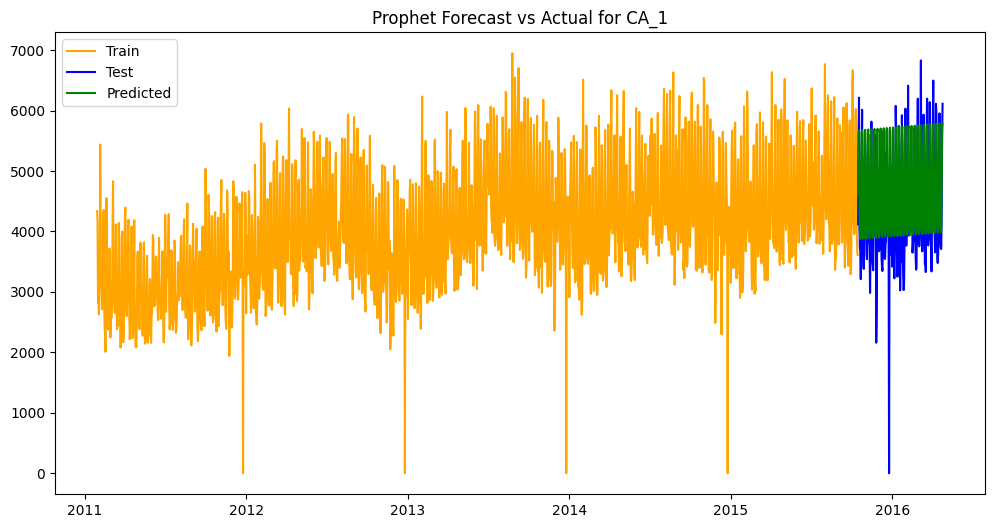

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train_df['ds'], train_df['y'], label='Train', color='orange')
plt.plot(test_df['ds'], test_df['y'], label='Test', color='blue')
plt.plot(test_df['ds'], y_pred, label='Predicted', color='green')
plt.title("Prophet Forecast vs Actual for CA_1")
plt.legend()
plt.show()

### Evaluating Prophet Model Performance

1. **Compute RMSE:**  
   - `mean_squared_error(test_df['y'], y_pred)` calculates the mean squared error between actual sales (`test_df['y']`) and Prophet forecasts (`y_pred`).  
   - `math.sqrt()` converts it to **root mean squared error (RMSE)** for easier interpretation.

2. **Store results:**  
   - Append the RMSE along with the model name to `model_results` for comparison with other models.

3. **Interpretation:**  
   - RMSE provides the average magnitude of forecast errors in the same units as sales.  
   - A lower RMSE indicates better forecast accuracy.

In [119]:
from sklearn.metrics import mean_squared_error
import math

rmse_prophet = math.sqrt(mean_squared_error(test_df['y'], y_pred))
model_results.append({
    "Model": "prophet",
    "RMSE": rmse_prophet 
})

model_results


[{'Model': 'SARIMAX (0,1,1)(0,1,1,7)', 'RMSE': 396.07947904626695},
 {'Model': 'SARIMAX (4,1,0)(2,1,1,7)', 'RMSE': 377.3091243549795},
 {'Model': 'ARIMA (4,1,2)', 'RMSE': 414.94287856478354},
 {'Model': 'prophet', 'RMSE': 644.8663833472237}]

                      Model        RMSE
0  SARIMAX (0,1,1)(0,1,1,7)  396.079479
1  SARIMAX (4,1,0)(2,1,1,7)  377.309124
2             ARIMA (4,1,2)  414.942879
3                   prophet  644.866383


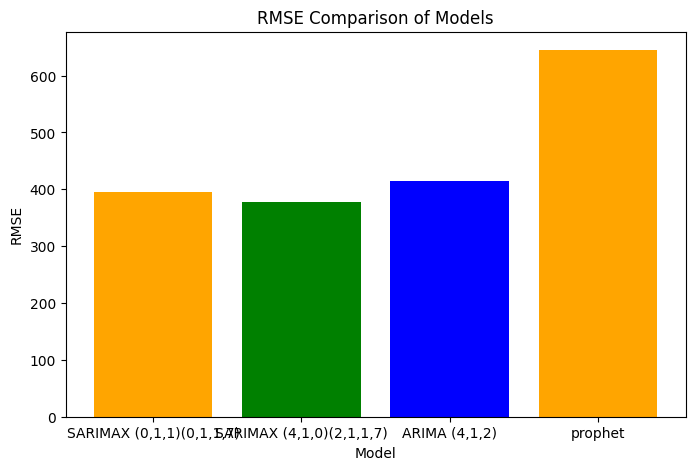

In [120]:
import matplotlib.pyplot as plt
import pandas as pd
results_df = pd.DataFrame(model_results)
print(results_df)
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'], color=['orange', 'green', 'blue'])
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### Preparing Store CA_1 Data for Forecasting

1. **Create a working copy:**  
   - `store_level_final.copy()` ensures the original dataset remains unchanged.

2. **Select relevant columns:**  
   - Only `date` and `CA_1` (sales for store CA_1) are kept for modeling.

3. **Ensure numeric data type:**  
   - Convert `CA_1` to `float` to avoid errors during modeling or plotting.

4. **Sort by date:**  
   - Sorting the data by `date` ensures the time series is in chronological order, which is required for most forecasting models.

In [122]:
data = store_level_final.copy()
data = data[['date', 'CA_1']]
data['CA_1'] = data['CA_1'].astype(float)
data = data.sort_values('date')

### Preparing Data for LSTM Model

1. **Scale the data:**  
   - `MinMaxScaler(feature_range=(0, 1))` scales the sales values (`CA_1`) to the range [0,1].  
   - Scaling helps the LSTM model converge faster and improves numerical stability.

2. **Create input-output sequences:**  
   - LSTM models require sequences of past observations as input to predict the next value.  
   - We define a `create_sequences` function that:
     - Takes a `time_step` number of previous observations as input (`X`).  
     - Uses the next observation as the target (`y`).  

3. **Set sequence length:**  
   - `time_step = 30` → each input sequence contains 30 consecutive days of sales.  

4. **Generate sequences:**  
   - `X, y = create_sequences(data['scaled'].values, time_step)` produces arrays ready for LSTM training:
     - `X` → shape `(num_samples, time_step)`  
     - `y` → shape `(num_samples,)` (next day sales)

In [123]:
scaler = MinMaxScaler(feature_range=(0, 1))
data['scaled'] = scaler.fit_transform(data[['CA_1']])
def create_sequences(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)
time_step = 30 
X, y = create_sequences(data['scaled'].values, time_step)

### Splitting and Reshaping Data for LSTM

1. **Train-test split:**  
   - `train_size = 90%` of the sequences for training.  
   - Remaining 10% are used for testing/validation.  
   - Resulting datasets: `X_train`, `X_test`, `y_train`, `y_test`.

2. **Reshape input for LSTM:**  
   - LSTM layers expect input shape `(samples, timesteps, features)`.  
   - Reshape `X_train` and `X_test` to add a **feature dimension** of 1 (since we have a univariate time series).  
   - After reshaping:
     - `X_train.shape` → `(num_train_samples, time_step, 1)`  
     - `X_test.shape` → `(num_test_samples, time_step, 1)`

3. **Purpose:**  
   - Ensures the data is compatible with Keras/TensorFlow LSTM layers for training and forecasting.

In [124]:
train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

### LSTM Hyperparameter Tuning for Store CA_1 Sales

1. **Train-validation split:**  
   - Split `X_train` and `y_train` into **training** and **validation** sets (80% train, 20% validation).  
   - `shuffle=False` to preserve the chronological order of the time series.

2. **Define hyperparameter grid:**  
   - `units` → number of LSTM neurons: `[32, 50]`  
   - `batch_size` → number of samples per gradient update: `[16, 32]`  
   - `epochs` → number of passes through the dataset: `[30, 50]`  
   - `optimizer` → optimization algorithm: `['adam', 'rmsprop']`

3. **Grid search procedure:**  
   - Iterate over all combinations of hyperparameters.  
   - Build a **Sequential LSTM model** with:
     - `Input(shape=(timesteps, features))`  
     - Single `LSTM` layer with specified units  
     - Output `Dense(1)` layer for prediction.  
   - Compile the model with **MSE loss** and the chosen optimizer.  
   - Train the model on `X_train_sub` and `y_train_sub`, validating on `X_val` and `y_val`.  
   - Track the **validation loss** of the last epoch for each configuration.

4. **Select best configuration:**  
   - Keep the combination of `(units, batch_size, epochs, optimizer)` that yields the **lowest validation loss**.  
   - Print the best LSTM configuration and corresponding validation loss for final model training.


In [128]:
import numpy as np
from keras import Input
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import math
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)
param_grid = {
    'units': [32, 50],
    'batch_size': [16, 32],
    'epochs': [30, 50],
    'optimizer': ['adam', 'rmsprop']
}

best_val_loss = np.inf
best_params = None

for units in param_grid['units']:
    for batch_size in param_grid['batch_size']:
        for epochs in param_grid['epochs']:
            for opt in param_grid['optimizer']:

                # Build model
                model = Sequential([
                    Input(shape=(timesteps, features)),
                    LSTM(units),
                    Dense(1)
                ])
                model.compile(optimizer=opt, loss='mse')
                history = model.fit(X_train_sub, y_train_sub,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(X_val, y_val),
                                    verbose=0)

                val_loss = history.history['val_loss'][-1]

                print(f"Tested: units={units}, batch_size={batch_size}, epochs={epochs}, optimizer={opt} → Val Loss={val_loss:.4f}")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_params = (units, batch_size, epochs, opt)

print("\n Best LSTM Config (based on validation loss):")
print(f"units={best_params[0]}, batch_size={best_params[1]}, epochs={best_params[2]}, optimizer={best_params[3]}, Val Loss={best_val_loss:.4f}")


Tested: units=32, batch_size=16, epochs=30, optimizer=adam → Val Loss=0.0055
Tested: units=32, batch_size=16, epochs=30, optimizer=rmsprop → Val Loss=0.0060
Tested: units=32, batch_size=16, epochs=50, optimizer=adam → Val Loss=0.0044
Tested: units=32, batch_size=16, epochs=50, optimizer=rmsprop → Val Loss=0.0048
Tested: units=32, batch_size=32, epochs=30, optimizer=adam → Val Loss=0.0060
Tested: units=32, batch_size=32, epochs=30, optimizer=rmsprop → Val Loss=0.0068
Tested: units=32, batch_size=32, epochs=50, optimizer=adam → Val Loss=0.0044
Tested: units=32, batch_size=32, epochs=50, optimizer=rmsprop → Val Loss=0.0075
Tested: units=50, batch_size=16, epochs=30, optimizer=adam → Val Loss=0.0044
Tested: units=50, batch_size=16, epochs=30, optimizer=rmsprop → Val Loss=0.0046
Tested: units=50, batch_size=16, epochs=50, optimizer=adam → Val Loss=0.0044
Tested: units=50, batch_size=16, epochs=50, optimizer=rmsprop → Val Loss=0.0051
Tested: units=50, batch_size=32, epochs=30, optimizer=adam

### Training and Evaluating Final LSTM Model for Store CA_1

1. **Define the model architecture:**  
   - Input layer with shape `(timesteps, features)` → here, `timesteps=30` and `features=1`  
   - Single `LSTM` layer with 50 units (best hyperparameter from tuning)  
   - Dense output layer with 1 neuron for predicting next-day sales

2. **Compile the model:**  
   - Optimizer: `adam`  
   - Loss function: mean squared error (MSE)

3. **Train the model:**  
   - Training on `X_train` and `y_train`  
   - Validation on `X_test` and `y_test`  
   - 50 epochs, batch size 16  
   - `history` stores training and validation loss for each epoch

4. **Make predictions:**  
   - `y_pred` is predicted scaled sales from the LSTM  
   - Reshape and **inverse transform** to get actual sales scale

5. **Evaluate model performance:**  
   - Compute **RMSE** between predicted and actual sales on the test set  
   - Append results to `model_results` for comparison with other models

6. **Purpose:**  
   - RMSE gives the average error magnitude in sales units  
   - Allows direct comparison of LSTM forecasts with ARIMA, SARIMAX, Holt-Winters, and Prophet models

In [126]:
from keras import Input
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt
model = Sequential([
    Input(shape=(timesteps, features)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),  
    verbose=1
)

y_pred = model.predict(X_test)
y_pred_2d = y_pred.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)
y_pred_rescaled = scaler.inverse_transform(y_pred_2d)
y_test_rescaled = scaler.inverse_transform(y_test_2d)
rmse_lstm = math.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f"LSTM RMSE: {rmse_lstm:.3f}")
model_results.append({
    "Model": "LSTM",
    "RMSE": rmse_lstm
})

model_results

Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0721 - val_loss: 0.0189
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0168 - val_loss: 0.0186
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0152 - val_loss: 0.0210
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0170 - val_loss: 0.0179
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0152 - val_loss: 0.0171
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0150 - val_loss: 0.0147
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0125 - val_loss: 0.0095
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0063 - val_loss: 0.0087
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0065 - val_loss: 0.0088
Epoch 10/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0082
Epoch 11/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0055 - val_loss: 0.0096
Epoch 12/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

[{'Model': 'SARIMAX (0,1,1)(0,1,1,7)', 'RMSE': 396.07947904626695},
 {'Model': 'SARIMAX (4,1,0)(2,1,1,7)', 'RMSE': 377.3091243549795},
 {'Model': 'ARIMA (4,1,2)', 'RMSE': 414.94287856478354},
 {'Model': 'prophet', 'RMSE': 644.8663833472237},
 {'Model': 'LSTM', 'RMSE': 539.285944038296}]

                      Model        RMSE
0  SARIMAX (0,1,1)(0,1,1,7)  396.079479
1  SARIMAX (4,1,0)(2,1,1,7)  377.309124
2             ARIMA (4,1,2)  414.942879
3                   prophet  644.866383
4                      LSTM  539.285944


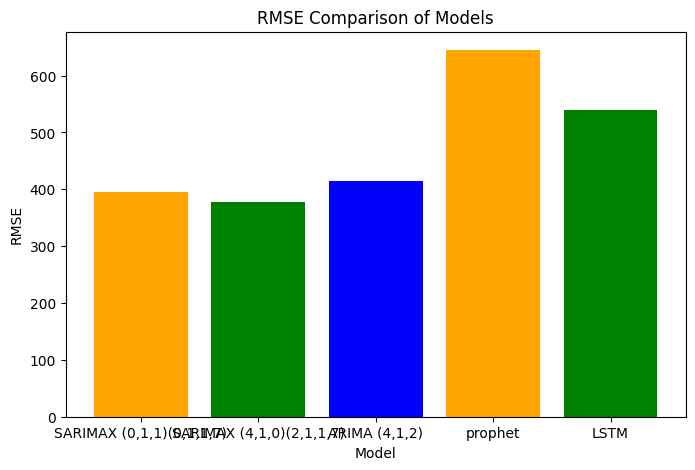

In [127]:
import matplotlib.pyplot as plt
import pandas as pd
results_df = pd.DataFrame(model_results)
print(results_df)
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'], color=['orange', 'green', 'blue'])
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()

### Comparison of Forecasting Models for Store CA_1

We evaluated multiple forecasting models using **RMSE** on the test set:

1. **SARIMAX (4,1,0)(2,1,1,7)** → RMSE: 377.31  
2. **SARIMAX (0,1,1)(0,1,1,7)** → RMSE: 396.08  
3. **ARIMA (4,1,2)** → RMSE: 414.94  
4. **LSTM** → RMSE: 539.29  
5. **Prophet** → RMSE: 644.87

In [ ]:
store_level

### Aggregating Sales by Category
- I group the sales data by **category (`cat_id`)** and compute total sales for each category.  
- I then **transpose** the DataFrame so that days (`d`) become rows instead of columns.  
- Finally, I add a `d` column to clearly represent the day-wise sales for each category.  

This transformation allows me to analyze and visualize **category-level sales trends** over time.  


In [ ]:
category_sales = sales_train_validation.groupby(sales_train_validation['cat_id']).sum()
category_salest = category_sales.transpose()
category_salest['d'] = category_salest.index

### Merging Category-Level Sales with Calendar
- I merge the transposed **category-level sales** DataFrame with the **calendar** dataset using the `d` column.  
- I convert the `date` column from string format to Python `datetime` objects for easier time-based analysis.  
- The resulting `category_level_final` DataFrame combines **category sales** with **calendar information**, enabling trend and seasonality analysis.  


In [ ]:
category_level_final = category_salest.merge(calendar, on='d')
category_level_final['date'] = category_level_final['date'].apply(lambda t: datetime.strptime(t, '%Y-%m-%d'))
category_level_final

### Handling Outliers for Christmas Events
- I create a copy of `category_level_final` called `category_level_model` for modeling purposes.  
- For days corresponding to **Christmas events**, I replace the sales values in each category (**FOODS, HOBBIES, HOUSEHOLD**) with the **category's average sales**.  
- This helps reduce the impact of **outliers caused by holiday spikes** on the model training.  


In [ ]:
category_level_model = category_level_final
category_level_model['FOODS'].loc[category_level_model['event_name_1'] == 'Christmas'] = category_level_final['FOODS'].mean()
category_level_model['HOBBIES'].loc[category_level_model['event_name_1'] == 'Christmas'] = category_level_final['HOBBIES'].mean()
category_level_model['HOUSEHOLD'].loc[category_level_model['event_name_1'] == 'Christmas'] = category_level_final['HOUSEHOLD'].mean()

In [ ]:
category_level_model

### SARIMA Modeling for FOODS Category
- I split the **FOODS** category sales into training (`train_food`) and testing (`test_food`) arrays.  
- I fit a **SARIMA model** with `order=(0,1,1)` and `seasonal_order=(0,1,1,7)` to capture both trend and weekly seasonality.  
- I plot the model **predictions** against the **test data** to visually assess forecasting performance.  
- I calculate the **Root Mean Squared Error (RMSE)** to quantify prediction accuracy and display it in the plot title.  


In [ ]:
train_food = np.asarray(category_level_model['FOODS'][0:1883].astype(float))
test_food = np.asarray(category_level_model['FOODS'][1883:-1].astype(float))

mod_food = sm.tsa.statespace.SARIMAX(train_food, order=(0,1,1), seasonal_order=(0,1,1,7))
results_food=mod_food.fit()
plt.plot(results_food.predict(start = len(train_food), end = 1911), label = 'Predicted')
plt.plot(test_food, label = 'Test')
plt.legend(loc = 'upper left')
rmse = math.sqrt(mean_squared_error(results_food.predict(start = 1883, end = 1911), test_food))
plt.title("Food: SARIMA Model Prediction vs. Test with RMSE = " + "{:.0f}".format(rmse))

### Forecasting FOODS Sales Beyond Training Period
I plot the **SARIMA model predictions** for the **FOODS** category from day 1800 to 2200.  
- This allows me to visualize the model’s forecast beyond the training period.  
- The plot helps in assessing how well the model captures trends and seasonality over a longer horizon.  


In [ ]:
plt.plot(results_food.predict(start = 1800, end = 2200), label = 'Predicted')

### SARIMA Modeling for HOBBIES Category
- I split the **HOBBIES** category sales into training (`train_hobbies`) and testing (`test_hobbies`) arrays.  
- I fit a **SARIMA model** with `order=(0,1,1)` and `seasonal_order=(0,1,1,7)` to capture both trend and weekly seasonality.  
- I plot the model **predictions** against the **test data** to visually assess forecasting performance.  
- I calculate the **Root Mean Squared Error (RMSE)** to quantify prediction accuracy and display it in the plot title.  


In [ ]:
train_hobbies = np.asarray(category_level_model['HOBBIES'][0:1883].astype(float))
test_hobbies = np.asarray(category_level_model['HOBBIES'][1883:-1].astype(float))
mod_hobbies = sm.tsa.statespace.SARIMAX(train_hobbies, order=(0,1,1), seasonal_order=(0,1,1,7))
results_hobbies = mod_hobbies.fit() 
plt.plot(results_hobbies.predict(start = len(train_hobbies), end = 1911), label = 'Predicted')
plt.plot(test_hobbies, label = 'Test')
plt.legend(loc = 'upper left')
rmse = math.sqrt(mean_squared_error(results_hobbies.predict(start = 1883, end = 1911), test_hobbies))
plt.title("Hobbies: SARIMA Model Prediction vs. Test with RMSE = " + "{:.0f}".format(rmse))

### SARIMA Modeling for HOUSEHOLD Category
- I split the **HOUSEHOLD** category sales into training (`train_household`) and testing (`test_household`) arrays.  
- I fit a **SARIMA model** with `order=(0,1,1)` and `seasonal_order=(0,1,1,7)` to capture trend and weekly seasonality.  
- I plot the model **predictions** against the **test data** to visually assess forecasting performance.  
- I calculate the **Root Mean Squared Error (RMSE)** to quantify prediction accuracy and display it in the plot title.  


In [ ]:
train_household = np.asarray(category_level_final['HOUSEHOLD'][0:1883].astype(float))
test_household = np.asarray(category_level_final['HOUSEHOLD'][1883:-1].astype(float))
mod_household = sm.tsa.statespace.SARIMAX(train_household, order=(0,1,1), seasonal_order=(0,1,1,7))
results_household = mod_household.fit()
plt.plot(results_household.predict(start = len(train_household), end = 1911), label = 'Predicted')
plt.plot(test_household, label = 'Test')
plt.legend(loc = 'upper left')
rmse = math.sqrt(mean_squared_error(results_household.predict(start = 1883, end = 1911), test_household))
plt.title("Household: SARIMA Model Prediction vs. Test with RMSE = " + "{:.0f}".format(rmse))

### Importing Exponential Smoothing
I import `ExponentialSmoothing` from `statsmodels.tsa.holtwinters` to apply **Holt-Winters smoothing** for time series forecasting.  
- This method can model **trend** and **seasonality** in the sales data.  
- It provides an alternative to SARIMA for comparison of forecasting performance.  


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### Holt-Winters Exponential Smoothing for Store CA_1
- I fit an **Exponential Smoothing** model on the training data with:  
  - `trend='add'` → additive trend  
  - `seasonal='add'` → additive seasonality  
  - `seasonal_periods=8` → weekly seasonality assumed  
- I then fit the model and print the **summary** to examine the estimated parameters and model diagnostics.  


In [ ]:
model_hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=8)
fit_hw = model_hw.fit()
print(fit_hw.summary())

### Visualizing Holt-Winters Predictions on Training Data
I plot the **Holt-Winters model predictions** for days 1800–1880 alongside the actual training data for **store CA_1**.  
- The plot helps me assess how well the model captures the recent **trend** and **seasonality** in the training data.  
- Legend distinguishes between actual sales (`Train`) and predicted values (`Predicted`).  


In [ ]:
plt.plot(fit_hw.predict(start = 1800, end = 1880), label = 'Predicted')
plt.plot(train[1800:1880], label = 'Train')
plt.legend(loc = "upper left")

In [ ]:
rmse = math.sqrt(mean_squared_error(fit_hw.predict(start = 1880, end = 1911), test))
rmse

### Evaluating Holt-Winters Model Performance
I calculate the **Root Mean Squared Error (RMSE)** between the Holt-Winters model predictions and the actual sales in the test set for **store CA_1**.  
- This provides a quantitative measure of the model's **forecasting accuracy**.  
- A lower RMSE indicates better predictive performance.  


### Holt-Winters Model RMSE
The **Root Mean Squared Error (RMSE)** of the Holt-Winters model on the test set is approximately **1,531**.  
- This means, on average, the model's predictions are off by about **1,531 units/day**.  
- Compared to SARIMA, this is a higher error, indicating that SARIMA may provide better forecasts for **store CA_1** in this case.  
